# **Naive Bayes Classifier**

#  Campus Message Detective — Naive Bayes Classifier

 **Important or Promotional?**

Imagine a college student receives **50–100 messages every week**:

-  academic announcements
-  assignment and exam reminders
-  placement notifications
-  event information
-  discounts, prizes and promotional messages

The challenge:

> **Can a machine learn from previously labelled messages and automatically decide whether a new message is Important or Promotional?**

In this mini-project, we will build a **Naive Bayes text classifier**.




Suppose the college has an **AI-powered message filter**.

A new message arrives:

> **"Submit your project report before 5 PM tomorrow."**

The model asks:

**Which class is more probable?**

- `P(Important | message)`
- `P(Promotional | message)`

Naive Bayes uses the evidence contained in the words of the message to compare these probabilities.

The word **"submit"**, for example, may occur frequently in Important messages, while words such as **"free"**, **"offer"**, **"win"**, and **"claim"** may be strongly associated with Promotional messages.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Create our mini dataset

To keep the project self-contained, we will create a small dataset directly in the notebook.

Each record contains:

- `message` → the text received by the student
- `label` → the correct class

This is a **teaching dataset**, not a production spam dataset.


In [3]:
# Create the dataset
data = [('Buy one get one free. Shop now and save big.', 'Promotional'), ('The attendance report will be finalized this week.', 'Important'), ('Reminder: the coding contest closes tonight, register before 11 PM.', 'Important'), ("The classroom for today's lecture has changed to Room 204.", 'Important'), ('The placement aptitude test is scheduled for Saturday.', 'Important'), ('Students selected for the internship should report to the training office.', 'Important'), ('The student portal is under maintenance from 8 PM to 10 PM.', 'Important'), ('Please confirm your participation in the workshop by tomorrow.', 'Important'), ('Mega sale starts now. Up to 70 percent discount.', 'Promotional'), ('The coding contest registration closes tonight.', 'Important'), ('The seminar on Generative AI starts at 2 PM in Seminar Hall.', 'Important'), ('Special student discount available. Click to activate.', 'Promotional'), ('Free recharge available for selected users. Claim now.', 'Promotional'), ('Special offer just for you. Click here before it ends.', 'Promotional'), ('You are selected for a special cashback reward.', 'Promotional'), ('Your exclusive bonus is ready. Click now to claim it.', 'Promotional'), ('Your internal assessment marks are available on the portal.', 'Important'), ('The timetable for the next semester is now available.', 'Important'), ('Your lucky number has won a shopping voucher.', 'Promotional'), ("Bring your laptop for tomorrow's Python practical.", 'Important'), ('Exclusive offer! Get a free gift voucher today.', 'Promotional'), ('Students must submit the project synopsis by Wednesday.', 'Important'), ('Unlock your exclusive coupon and save money today.', 'Promotional'), ('Your project presentation slot is at 10:30 AM.', 'Important'), ('You have been chosen for a surprise reward.', 'Promotional'), ('The department meeting for student representatives is on Friday.', 'Important'), ("Tomorrow's Machine Learning lecture is shifted to 11 AM.", 'Important'), ('Congratulations! You won a free smartphone. Claim it now.', 'Promotional'), ('Congratulations! You qualify for a bonus reward.', 'Promotional'), ('The examination form must be submitted before the deadline.', 'Important'), ('Hurry! Your chance to win a brand new laptop ends tonight.', 'Promotional'), ('Get instant cashback on your next purchase.', 'Promotional'), ('Get 80 percent off on shoes. Limited time offer!', 'Promotional'), ('Your viva will be conducted after the practical examination.', 'Important'), ('Flash sale! Grab your favorite products before midnight.', 'Promotional'), ('Claim your free movie tickets before they expire.', 'Promotional'), ('Act now to receive your complimentary gift.', 'Promotional'), ('The deadline for course registration is tomorrow.', 'Important'), ('Get premium membership at an unbelievable price.', 'Promotional'), ('A special discount is waiting for you. Shop before midnight.', 'Promotional'), ('The NLP practical will be conducted in Lab 3 tomorrow.', 'Important'), ('Win exciting prizes by clicking this lucky link.', 'Promotional'), ('Limited offer! Free delivery on all orders today.', 'Promotional'), ('The university exam timetable has been published.', 'Important'), ('Congratulations winner! Send your details to receive the prize.', 'Promotional'), ('Win a travel package by participating in our contest.', 'Promotional'), ('Attendance shortage students should meet the class coordinator.', 'Important'), ('Congratulations on your achievement! Collect your certificate from the office.', 'Important'), ('Download the question bank from the LMS before the next lecture.', 'Important'), ('Please check your university email for the internship instructions.', 'Important'), ('The faculty has uploaded notes for the next unit.', 'Important'), ('Bring your identity card for the campus recruitment drive.', 'Important'), ("Don't miss our biggest sale of the year.", 'Promotional'), ('Submit the Deep Learning assignment before Friday 5 PM.', 'Important'), ('The project review is scheduled for Monday morning.', 'Important'), ('Earn easy money from home. Join our program today.', 'Promotional')]

df = pd.DataFrame(data, columns=["message", "label"])

print("Dataset shape:", df.shape)
display(df.head(10))


Dataset shape: (56, 2)


,message,label
0,Buy one get one free. Shop now and save big.,Promotional
1,The attendance report will be finalized this w...,Important
2,"Reminder: the coding contest closes tonight, r...",Important
3,The classroom for today's lecture has changed ...,Important
4,The placement aptitude test is scheduled for S...,Important
5,Students selected for the internship should re...,Important
6,The student portal is under maintenance from 8...,Important
7,Please confirm your participation in the works...,Important
8,Mega sale starts now. Up to 70 percent discount.,Promotional
9,The coding contest registration closes tonight.,Important


Class distribution:


,count
label,
Important,29
Promotional,27



Missing values:
message    0
label      0
dtype: int64


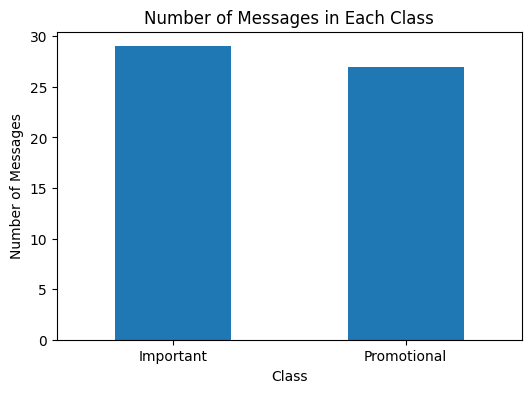

In [ ]:
# Inspect the dataset
print("Class distribution:")
display(df["label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

# Visualize class distribution
df["label"].value_counts().plot(kind="bar", rot=0, figsize=(6,4))
plt.title("Number of Messages in Each Class")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()


## 2. Why do we need to convert text into numbers?

A machine-learning algorithm cannot directly work with:

> `"Submit your assignment before Friday"`

It needs numerical features.

One simple approach is **Bag of Words (BoW)**.

Suppose our tiny dataset contains:

- `"free gift today"`
- `"submit assignment today"`

The vocabulary might become:

`[assignment, free, gift, submit, today]`

A message is then represented by word counts.

For example:

`"free gift today"` → `[0, 1, 1, 0, 1]`

This is exactly the type of representation that **Multinomial Naive Bayes** works very well with.


In [ ]:
# Separate input (X) and target (y)
X = df["message"]
y = df["label"]

# Split before fitting the vectorizer to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages :", len(X_test))


Training messages: 42
Testing messages : 14


In [ ]:
# Convert text into Bag-of-Words features
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_bow.shape)
print("Testing matrix shape :", X_test_bow.shape)

print("\nFirst 30 vocabulary words:")
print(vectorizer.get_feature_names_out()[:30])


Training matrix shape: (42, 157)
Testing matrix shape : (14, 157)

First 30 vocabulary words:
['10' '11' '204' '30' '70' 'achievement' 'activate' 'ai' 'aptitude'
 'assessment' 'assignment' 'attendance' 'available' 'bank' 'big' 'biggest'
 'bonus' 'brand' 'bring' 'buy' 'campus' 'card' 'cashback' 'certificate'
 'chance' 'changed' 'check' 'chosen' 'claim' 'class']


In [ ]:
# See what Bag-of-Words actually looks like
bow_sample = pd.DataFrame(
    X_train_bow[:5].toarray(),
    columns=vectorizer.get_feature_names_out()
)

display(bow_sample)


,10,11,204,30,70,achievement,activate,ai,aptitude,assessment,...,uploaded,users,viva,voucher,waiting,wednesday,week,win,won,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


## 3. The Naive Bayes idea

Bayes' theorem tells us how to update a probability after observing evidence.

For a class `C` and observed message `X`:

**Posterior ∝ Likelihood × Prior**

For text classification, Naive Bayes estimates:

- **Prior:** How common is each class?
- **Likelihood:** How frequently do words occur in each class?
- **Posterior:** Given these words, which class is most likely?

### Why is it called "Naive"?

Because it makes a simplifying assumption:

> It treats the features (words) as conditionally independent given the class.

Natural language does **not** really satisfy this assumption.  
Nevertheless, this simple assumption often works surprisingly well for text classification.

The multinomial version is especially suitable when features represent **word counts**.


## 4. Train the Multinomial Naive Bayes model

The workflow is now very small:

**Text → Bag of Words → Naive Bayes → Prediction**

We use `MultinomialNB` because our features are word counts.


In [ ]:
# Create and train the Naive Bayes classifier
model = MultinomialNB()

model.fit(X_train_bow, y_train)

print("Naive Bayes model trained successfully!")


Naive Bayes model trained successfully!


In [ ]:
# Make predictions
y_pred = model.predict(X_test_bow)

print("Predictions:")
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Message": X_test.values
})

display(comparison)


Predictions:


,Actual,Predicted,Message
0,Important,Important,Please confirm your participation in the works...
1,Important,Promotional,The timetable for the next semester is now ava...
2,Promotional,Promotional,Get 80 percent off on shoes. Limited time offer!
3,Promotional,Promotional,Act now to receive your complimentary gift.
4,Important,Important,The NLP practical will be conducted in Lab 3 t...
5,Important,Important,The university exam timetable has been published.
6,Important,Important,The department meeting for student representat...
7,Promotional,Important,Congratulations winner! Send your details to r...
8,Promotional,Promotional,Unlock your exclusive coupon and save money to...
9,Promotional,Promotional,Get instant cashback on your next purchase.


## 5. Evaluate the classifier

Accuracy tells us the overall percentage of correct predictions.

But we also want to know:

- Which Important messages were correctly identified?
- Which Promotional messages were correctly identified?
- Did the model confuse one class with the other?

For this, we use a **confusion matrix** and **classification report**.


Accuracy: 85.71%

Classification Report:
              precision    recall  f1-score   support

   Important       0.86      0.86      0.86         7
 Promotional       0.86      0.86      0.86         7

    accuracy                           0.86        14
   macro avg       0.86      0.86      0.86        14
weighted avg       0.86      0.86      0.86        14



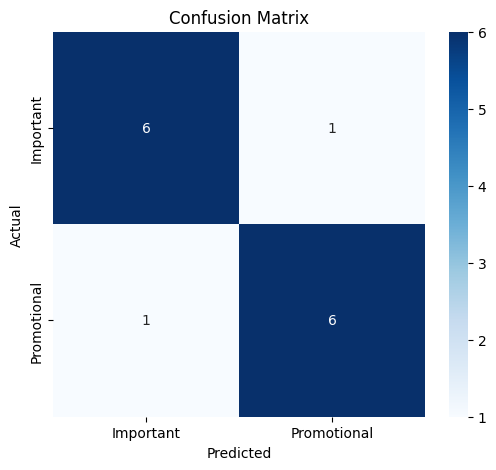

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["Important", "Promotional"])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Important", "Promotional"],
    yticklabels=["Important", "Promotional"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 6. classify brand-new messages

Our model has never seen these messages before.

Let's become the student and test it!


In [ ]:
new_messages = [
    "Please submit your machine learning assignment by tomorrow.",
    "Congratulations! Claim your free gift now.",
    "The placement aptitude test starts at 9 AM on Saturday.",
    "Win a brand new phone by clicking this link.",
    "The seminar hall has been changed to Room 301.",
    "Get 70 percent discount today. Limited offer!",
    "Your project viva is scheduled for Monday.",
    "You have won an exclusive cashback reward."
]

new_bow = vectorizer.transform(new_messages)
new_predictions = model.predict(new_bow)
new_probabilities = model.predict_proba(new_bow)

results = pd.DataFrame({
    "Message": new_messages,
    "Prediction": new_predictions,
    "Confidence": new_probabilities.max(axis=1)
})

display(results)


,Message,Prediction,Confidence
0,Please submit your machine learning assignment...,Important,0.992164
1,Congratulations! Claim your free gift now.,Promotional,0.981202
2,The placement aptitude test starts at 9 AM on ...,Important,0.933639
3,Win a brand new phone by clicking this link.,Promotional,0.986447
4,The seminar hall has been changed to Room 301.,Important,0.956654
5,Get 70 percent discount today. Limited offer!,Promotional,0.995640
6,Your project viva is scheduled for Monday.,Important,0.920259
7,You have won an exclusive cashback reward.,Promotional,0.981202


## 7. Look inside the model

One of the best ways to understand Naive Bayes is to inspect the words associated with each class.

The model stores estimated log-probabilities for every vocabulary word.

A useful classroom question:

> **Which words have the strongest association with Promotional messages?**

Let's find out.


In [ ]:
# Inspect important words for each class
feature_names = vectorizer.get_feature_names_out()

class_names = model.classes_

for class_index, class_name in enumerate(class_names):
    log_probs = model.feature_log_prob_[class_index]
    top_indices = np.argsort(log_probs)[-10:][::-1]

    print(f"\nTop words associated with: {class_name}")
    for idx in top_indices:
        print(f"{feature_names[idx]:15s} {log_probs[idx]:.3f}")



Top words associated with: Important
pm              -3.821
students        -4.227
tomorrow        -4.227
lecture         -4.227
submit          -4.515
report          -4.515
office          -4.515
practical       -4.515
portal          -4.515
seminar         -4.515

Top words associated with: Promotional
free            -3.777
special         -3.959
win             -4.182
reward          -4.182
offer           -4.182
sale            -4.182
discount        -4.182
claim           -4.182
click           -4.182
shop            -4.470


**Test the Naive Bayes Model with a New Message**

In [ ]:

# Take message from the user
new_message = input("Enter your message: ")

# Convert the message into the same Bag-of-Words representation
new_message_vector = vectorizer.transform([new_message])

# Make prediction
prediction = model.predict(new_message_vector)[0]

# Get prediction probabilities
probabilities = model.predict_proba(new_message_vector)[0]

# Get class names
classes = model.classes_

# Display result
print("\n" + "=" * 50)
print("              PREDICTION RESULT")
print("=" * 50)

print(f"\nMessage: {new_message}")

if prediction == "Important":
    print("\n Prediction: IMPORTANT")
else:
    print("\n Prediction: PROMOTIONAL")

# Display probabilities
print("\nProbability:")
for class_name, probability in zip(classes, probabilities):
    print(f"   {class_name}: {probability:.2%}")

print(f"\nModel Confidence: {max(probabilities):.2%}")
print("=" * 50)

Enter your message: Please complete you assignment

              PREDICTION RESULT

Message: Please complete you assignment

 Prediction: IMPORTANT

Probability:
   Important: 67.78%
   Promotional: 32.22%

Model Confidence: 67.78%


In [ ]:
import joblib

# Save trained model
joblib.dump(model, "naive_bayes_model.pkl")

# Save text vectorizer
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Exercise for Students

Write html and flask code to do ene-to-end project.

### 1 — Add your own messages
Add at least **10 new messages** from your own college context.

Examples:
- workshop announcements
- exam notices
- placement messages
- scholarship information
- event invitations
- shopping offers




**Flask Code :-**

In [ ]:
from flask import Flask, render_template, request
import joblib

app = Flask(__name__)


# =========================================================
# LOAD TRAINED MODEL AND VECTORIZER
# =========================================================

vectorizer = joblib.load("vectorizer.pkl")
model = joblib.load("naive_bayes_model.pkl")


# =========================================================
# 12 NEW COLLEGE-CONTEXT MESSAGES
# =========================================================

college_messages = [
    {
        "category": "Workshop Announcement",
        "message": "A hands-on Artificial Intelligence workshop will be conducted in the Computer Lab on Friday at 10 AM."
    },
    {
        "category": "Exam Notice",
        "message": "The internal examination timetable has been released. Students must check the schedule on the college portal."
    },
    {
        "category": "Placement Notification",
        "message": "The placement cell has announced a campus recruitment drive. Eligible students must register before Wednesday."
    },
    {
        "category": "Scholarship Information",
        "message": "Students eligible for the government scholarship must submit the required documents to the college office before the deadline."
    },
    {
        "category": "College Event",
        "message": "The annual technical festival will be held next week. Students interested in participating should register with their department."
    },
    {
        "category": "Assignment Reminder",
        "message": "Students must submit the Machine Learning assignment on the LMS before Friday evening."
    },
    {
        "category": "Practical Notice",
        "message": "The DBMS practical examination will be conducted in Lab 2 tomorrow. Students should bring their lab manual."
    },
    {
        "category": "Lecture Update",
        "message": "Today's Data Science lecture has been shifted to Room 305 and will begin at 11 AM."
    },
    {
        "category": "Internship Notice",
        "message": "Students selected for the summer internship must report to the training and placement office tomorrow."
    },
    {
        "category": "Coding Competition",
        "message": "Registration is open for the college coding competition. Interested students should register before the closing date."
    },
    {
        "category": "Shopping Offer",
        "message": "Exclusive student offer! Get 60 percent off on selected products. Shop now and claim your discount."
    },
    {
        "category": "Prize Promotion",
        "message": "Congratulations! You have been selected for a special reward. Click the link now to claim your free gift."
    }
]


# =========================================================
# HOME PAGE
# =========================================================

@app.route("/", methods=["GET", "POST"])
def home():

    prediction = None
    message = ""
    selected_category = ""
    probabilities = None

    if request.method == "POST":

        # Get selected message number
        selected_index = request.form.get("selected_message")

        # Get custom message
        custom_message = request.form.get("custom_message", "").strip()

        # -------------------------------------------------
        # If user entered a custom message, use that
        # Otherwise use selected college message
        # -------------------------------------------------

        if custom_message:
            message = custom_message
            selected_category = "Custom Message"

        elif selected_index is not None and selected_index != "":
            index = int(selected_index)

            if 0 <= index < len(college_messages):
                message = college_messages[index]["message"]
                selected_category = college_messages[index]["category"]

        # -------------------------------------------------
        # CLASSIFICATION
        # -------------------------------------------------

        if message:

            # Convert message using the SAME vectorizer
            # used during training
            message_vector = vectorizer.transform([message])

            # Predict class
            prediction = model.predict(message_vector)[0]

            # Get prediction probabilities
            probability_values = model.predict_proba(message_vector)[0]

            # Get class names from the trained model
            class_names = model.classes_

            probabilities = []

            for class_name, probability in zip(
                class_names, probability_values
            ):
                probabilities.append({
                    "class": class_name,
                    "probability": round(probability * 100, 2)
                })


    return render_template(
        "index.html",
        messages=college_messages,
        prediction=prediction,
        message=message,
        selected_category=selected_category,
        probabilities=probabilities
    )


# =========================================================
# RUN FLASK APPLICATION
# =========================================================

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code :-**

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Campus Message Detective</title>

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
            font-family: Arial, sans-serif;
        }

        body {
            background: #f4f6f9;
            color: #222;
            padding: 30px;
        }

        .container {
            max-width: 1000px;
            margin: auto;
        }

        .header {
            background: #1f3c88;
            color: white;
            padding: 30px;
            border-radius: 15px;
            text-align: center;
            margin-bottom: 25px;
        }

        .header h1 {
            margin-bottom: 10px;
            font-size: 32px;
        }

        .header p {
            font-size: 16px;
        }

        .card {
            background: white;
            padding: 25px;
            border-radius: 15px;
            margin-bottom: 25px;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.08);
        }

        .card h2 {
            margin-bottom: 18px;
            color: #1f3c88;
        }

        label {
            display: block;
            margin-bottom: 8px;
            font-weight: bold;
        }

        select,
        textarea {
            width: 100%;
            padding: 13px;
            border: 1px solid #ccc;
            border-radius: 8px;
            margin-bottom: 18px;
            font-size: 15px;
        }

        select {
            background: white;
        }

        textarea {
            min-height: 120px;
            resize: vertical;
        }

        .button {
            width: 100%;
            padding: 14px;
            background: #1f3c88;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 17px;
            font-weight: bold;
            cursor: pointer;
        }

        .button:hover {
            background: #162d68;
        }

        .result {
            text-align: center;
            padding: 25px;
            border-radius: 12px;
            margin-top: 20px;
        }

        .important {
            background: #e8f5e9;
            border: 2px solid #43a047;
        }

        .promotional {
            background: #fff3e0;
            border: 2px solid #fb8c00;
        }

        .result h2 {
            margin-bottom: 10px;
        }

        .prediction {
            font-size: 30px;
            font-weight: bold;
            margin: 10px 0;
        }

        .message-box {
            background: #f7f7f7;
            padding: 15px;
            border-radius: 8px;
            margin-top: 15px;
            text-align: left;
        }

        .probability {
            margin-top: 15px;
        }

        .probability-row {
            margin-bottom: 12px;
        }

        .probability-label {
            display: flex;
            justify-content: space-between;
            margin-bottom: 5px;
        }

        .bar-container {
            width: 100%;
            height: 20px;
            background: #ddd;
            border-radius: 10px;
            overflow: hidden;
        }

        .bar {
            height: 100%;
            background: #1f3c88;
        }

        .messages-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 15px;
        }

        .message-item {
            border: 1px solid #ddd;
            padding: 15px;
            border-radius: 10px;
            background: #fafafa;
        }

        .message-number {
            font-weight: bold;
            color: #1f3c88;
            margin-bottom: 6px;
        }

        .message-category {
            font-size: 13px;
            font-weight: bold;
            color: #555;
            margin-bottom: 8px;
        }

        .message-text {
            font-size: 14px;
            line-height: 1.5;
        }

        .info {
            background: #eef3ff;
            border-left: 5px solid #1f3c88;
            padding: 15px;
            margin-bottom: 20px;
            border-radius: 5px;
            line-height: 1.6;
        }

        @media (max-width: 700px) {

            body {
                padding: 15px;
            }

            .messages-grid {
                grid-template-columns: 1fr;
            }

            .header h1 {
                font-size: 25px;
            }
        }

    </style>

</head>


<body>

<div class="container">

    <!-- HEADER -->

    <div class="header">

        <h1>Campus Message Detective</h1>

        <p>
            Naive Bayes Classifier for College Messages
        </p>

    </div>


    <!-- INFORMATION -->

    <div class="card">

        <div class="info">

            <strong>How it works:</strong>

            Select a college message or enter your own message.
            The trained Naive Bayes model will classify it as
            <strong>Important</strong> or
            <strong>Promotional</strong>.

        </div>


        <!-- FORM -->

        <form method="POST">

            <label for="selected_message">
                Select a College Message
            </label>

            <select
                name="selected_message"
                id="selected_message"
            >

                <option value="">
                    -- Select a message --
                </option>

                {% for item in messages %}

                <option value="{{ loop.index0 }}">

                    {{ loop.index }}.
                    {{ item.category }}

                </option>

                {% endfor %}

            </select>


            <label for="custom_message">
                Or Enter Your Own Message
            </label>

            <textarea
                name="custom_message"
                id="custom_message"
                placeholder="Example: The examination form submission deadline is tomorrow."
            ></textarea>


            <button
                type="submit"
                class="button"
            >

                Classify Message

            </button>

        </form>

    </div>


    <!-- RESULT -->

    {% if prediction %}

    <div class="card">

        <div class="result
            {% if prediction == 'Important' %}
                important
            {% else %}
                promotional
            {% endif %}
        ">

            <h2>Classification Result</h2>

            <div class="prediction">

                {{ prediction }}

            </div>

            <p>
                The Naive Bayes model classified this message as
                <strong>{{ prediction }}</strong>.
            </p>


            <div class="message-box">

                <strong>Message:</strong>

                <p style="margin-top: 8px;">
                    {{ message }}
                </p>

                <br>

                <strong>Selected Category:</strong>

                <p style="margin-top: 5px;">
                    {{ selected_category }}
                </p>

            </div>


            <!-- PROBABILITIES -->

            {% if probabilities %}

            <div class="probability">

                <h3 style="margin-bottom: 15px;">
                    Prediction Probability
                </h3>


                {% for item in probabilities %}

                <div class="probability-row">

                    <div class="probability-label">

                        <span>
                            {{ item.class }}
                        </span>

                        <span>
                            {{ item.probability }}%
                        </span>

                    </div>


                    <div class="bar-container">

                        <div
                            class="bar"
                            data-width="{{ item.probability }}">
                        </div>

                    </div>

                </div>

                {% endfor %}

            </div>

            {% endif %}

        </div>

    </div>

    {% endif %}


    <!-- 12 NEW MESSAGES -->

    <div class="card">

        <h2>
            Added College-Context Messages
        </h2>

        <p style="margin-bottom: 20px; color: #555;">

            These are the new messages added for testing
            the trained Naive Bayes classifier.

        </p>


        <div class="messages-grid">

            {% for item in messages %}

            <div class="message-item">

                <div class="message-number">

                    Message {{ loop.index }}

                </div>

                <div class="message-category">

                    {{ item.category }}

                </div>

                <div class="message-text">

                    {{ item.message }}

                </div>

            </div>

            {% endfor %}

        </div>

    </div>


    <!-- FOOTER -->

    <div style="
        text-align: center;
        padding: 20px;
        color: #666;
    ">

        <p>
            Campus Message Detective |
            Multinomial Naive Bayes
        </p>

    </div>

</div>

<script>
    document.querySelectorAll(".bar").forEach(function(bar) {
        const width = bar.getAttribute("data-width");
        bar.style.width = width + "%";
    });
</script>

</body>

</html>

SyntaxError: invalid decimal literal (2545440156.py, line 29)